In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# Prepare the Pareto dataframe
# ============================================================

df = pd.read_csv("pareto_dominating_points.csv")

pareto_df = df.copy()

pareto_df["T_DT"] = pareto_df["Y_TDT"]
pareto_df["rhoR_DT"] = pareto_df["Y_rhoRDT"]

# Convert the maximisation objective back to physical peak IFAR
pareto_df["peak_IFAR"] = -pareto_df["Y_minus_peak_IFAR"]

required_columns = [
    "T_DT",
    "rhoR_DT",
    "peak_IFAR",
]

pareto_df = (
    pareto_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=required_columns)
)

print(pareto_df[required_columns].head())

          T_DT   rhoR_DT  peak_IFAR
0  3905.939944  3.223999   6.331749
1  3745.339903  3.072769   6.164238
2  3741.361277  2.381290   5.979618
3  3591.643920  2.466602   5.969045
4  3572.463175  3.631321   6.195008


In [4]:
def plot_pareto_tradeoffs(
    pareto_df,
    colour_by="laser_energy",
    point_size=55,
    alpha=0.85,
    save_path=None,
):
    """
    Plot the three objective-objective trade-offs for the fixed 20 MA run.

    Parameters
    ----------
    pareto_df : pandas.DataFrame
        Dataframe containing the dominating points.

    colour_by : str
        Input or diagnostic used to colour the points.

        Examples:
            "laser_energy"
            "R_outer"
            "Pi_parameter"
            "Be_thickness"
            "rho_gas"
            "DT_ice_thickness"

    point_size : float
        Scatter-point size.

    alpha : float
        Scatter-point transparency.

    save_path : str or None
        Optional output filename.
    """

    required = [
        "T_DT",
        "rhoR_DT",
        "peak_IFAR",
        colour_by,
    ]

    missing = [
        column for column in required
        if column not in pareto_df.columns
    ]

    if missing:
        raise KeyError(
            f"Missing columns: {missing}\n\n"
            f"Available columns:\n{pareto_df.columns.tolist()}"
        )

    plot_data = (
        pareto_df[required]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    tradeoffs = [
        {
            "x": "rhoR_DT",
            "y": "T_DT",
            "xlabel": r"DT fuel $\rho R$",
            "ylabel": r"DT fuel temperature $T_{DT}$",
            "title": r"$T_{DT}$ vs $\rho R_{DT}$",
        },
        {
            "x": "T_DT",
            "y": "peak_IFAR",
            "xlabel": r"DT fuel temperature $T_{DT}$",
            "ylabel": "Peak IFAR",
            "title": r"Peak IFAR vs $T_{DT}$",
        },
        {
            "x": "rhoR_DT",
            "y": "peak_IFAR",
            "xlabel": r"DT fuel $\rho R$",
            "ylabel": "Peak IFAR",
            "title": r"Peak IFAR vs $\rho R_{DT}$",
        },
    ]

    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(18, 5.5),
        constrained_layout=True,
    )

    scatter = None

    for ax, plot_info in zip(axes, tradeoffs):
        scatter = ax.scatter(
            plot_data[plot_info["x"]],
            plot_data[plot_info["y"]],
            c=plot_data[colour_by],
            cmap="viridis_r",
            s=point_size,
            alpha=alpha,
            edgecolors="black",
            linewidths=0.4,
        )

        ax.set_xlabel(plot_info["xlabel"])
        ax.set_ylabel(plot_info["ylabel"])
        ax.set_title(plot_info["title"])
        ax.grid(alpha=0.3)

    colourbar = fig.colorbar(
        scatter,
        ax=axes,
        shrink=0.9,
        pad=0.02,
    )

    colourbar.set_label(
        colour_by.replace("_", " ")
    )

    fig.suptitle(
        f"Pareto trade-offs at fixed current: 20 MA coloured by {colour_by} ",
        fontsize=16,
    )

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

In [5]:
import numpy as np

# Material densities in kg/m^3
rho_be = 1.85e3
rho_ice = 0.92e3

# Inner radius of the Be liner
pareto_df["R_Be_inner"] = (
    pareto_df["R_outer"]
    - pareto_df["Be_thickness"]
)

# Total shell mass per unit length: Be + DT ice
pareto_df["m_shell_per_length"] = (
    pareto_df["Pi_parameter"]
    / pareto_df["R_outer"]**2
)

# Be liner mass per unit length
pareto_df["m_Be_per_length"] = (
    np.pi
    * (
        pareto_df["R_outer"]**2
        - pareto_df["R_Be_inner"]**2
    )
    * rho_be
)

# Remaining shell mass is DT ice
pareto_df["m_ice_per_length"] = (
    pareto_df["m_shell_per_length"]
    - pareto_df["m_Be_per_length"]
)

# Quantity inside the square root
pareto_df["R_ice_inner_squared"] = (
    pareto_df["R_Be_inner"]**2
    - pareto_df["m_ice_per_length"] / (np.pi * rho_ice)
)

# Mark invalid designs before taking the square root
valid_ice = (
    (pareto_df["R_Be_inner"] > 0)
    & (pareto_df["m_ice_per_length"] > 0)
    & (pareto_df["R_ice_inner_squared"] > 0)
)

pareto_df["R_ice_inner"] = np.nan

pareto_df.loc[valid_ice, "R_ice_inner"] = np.sqrt(
    pareto_df.loc[valid_ice, "R_ice_inner_squared"]
)

# DT ice thickness in metres
pareto_df["DT_ice_thickness"] = (
    pareto_df["R_Be_inner"]
    - pareto_df["R_ice_inner"]
)

# More readable version in millimetres
pareto_df["DT_ice_thickness_mm"] = (
    pareto_df["DT_ice_thickness"] * 1e3
)

print(
    pareto_df[
        [
            "R_outer",
            "Be_thickness",
            "Pi_parameter",
            "DT_ice_thickness",
            "DT_ice_thickness_mm",
        ]
    ].head()
)

print(f"Valid designs: {valid_ice.sum()} / {len(pareto_df)}")

    R_outer  Be_thickness  Pi_parameter  DT_ice_thickness  DT_ice_thickness_mm
0  0.003198      0.000075  1.204314e-07          0.000548             0.547616
1  0.003161      0.000085  1.206223e-07          0.000556             0.555598
2  0.003064      0.000165  1.207407e-07          0.000463             0.463472
3  0.003022      0.000190  1.181143e-07          0.000427             0.427079
4  0.003169      0.000085  1.207283e-07          0.000550             0.549748
Valid designs: 74 / 74


In [6]:
cols = [
    "R_outer",
    "Pi_parameter",
    "Be_thickness",
    "laser_energy",
    "rho_gas",
    "DT_ice_thickness_mm",
    "Y_TDT",
    "Y_rhoRDT",
    "Y_minus_peak_IFAR",
]

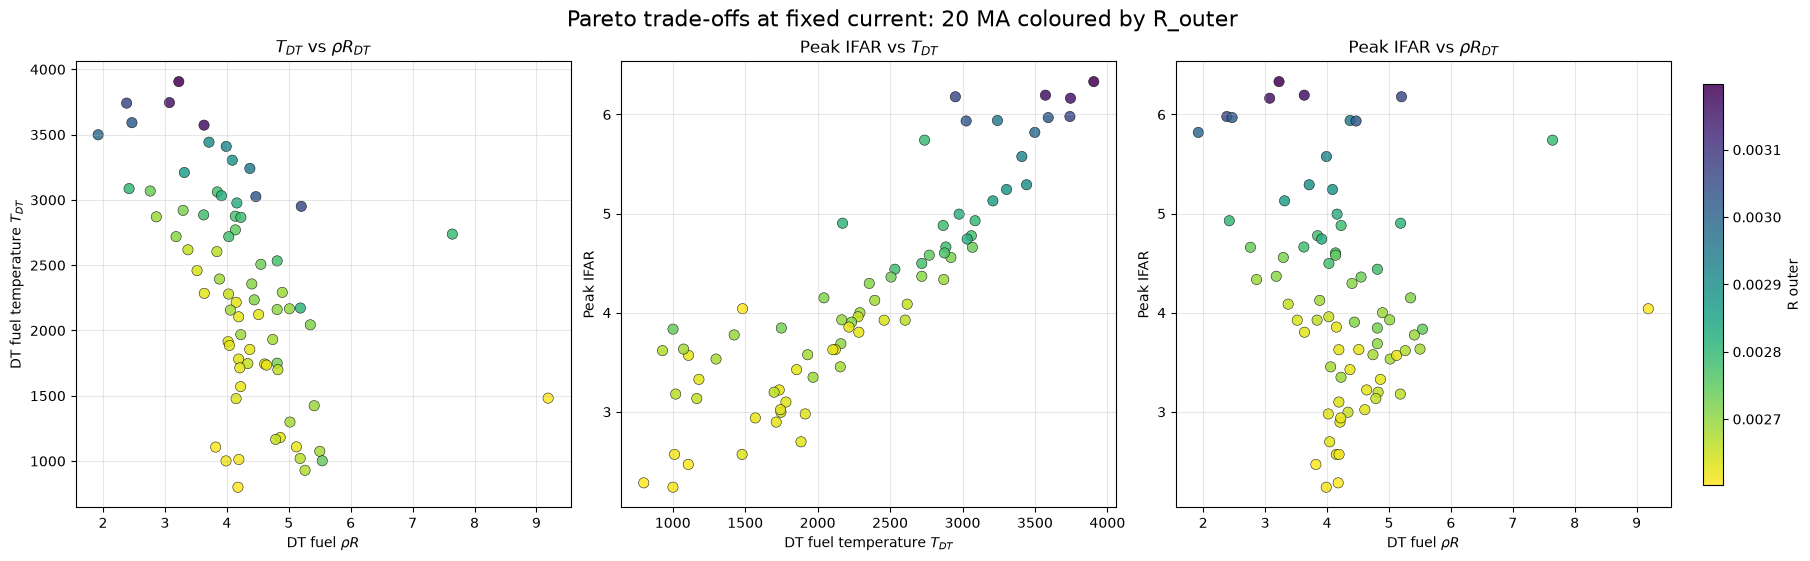

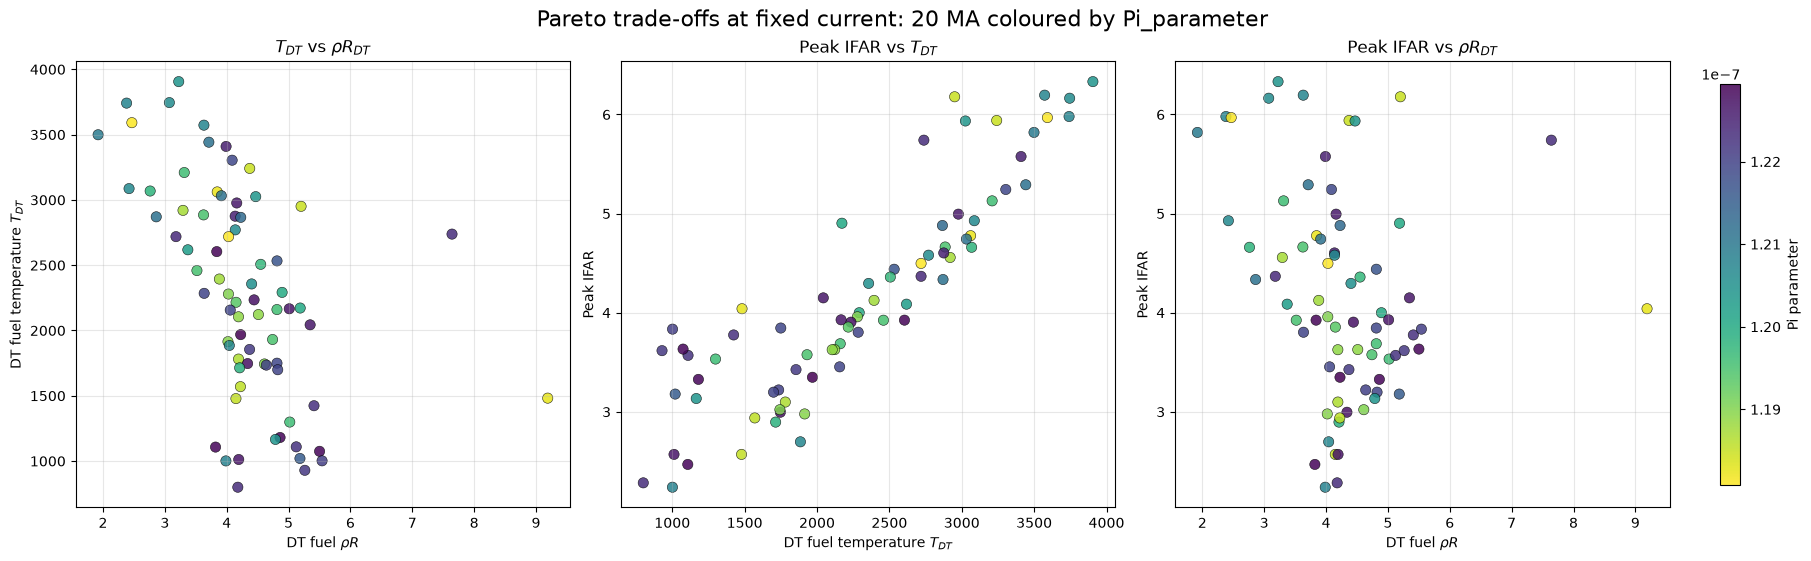

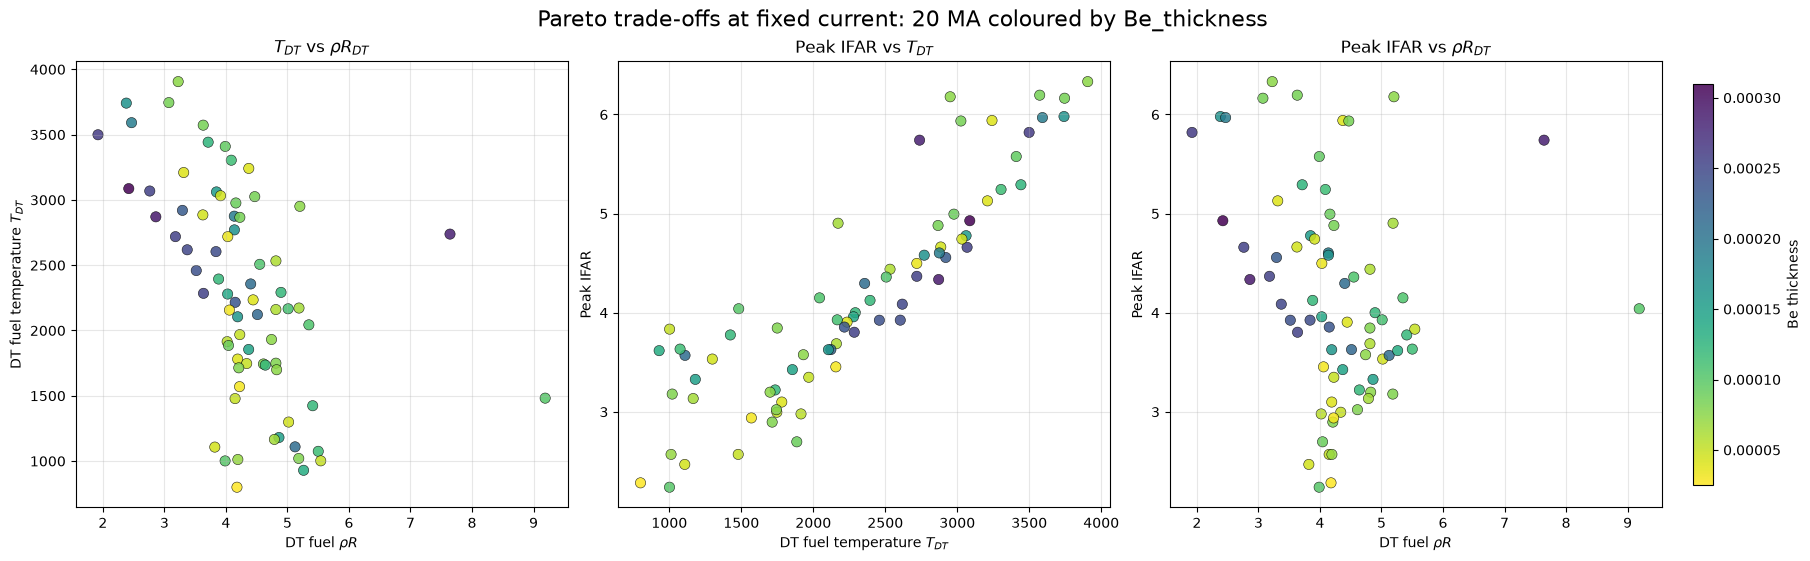

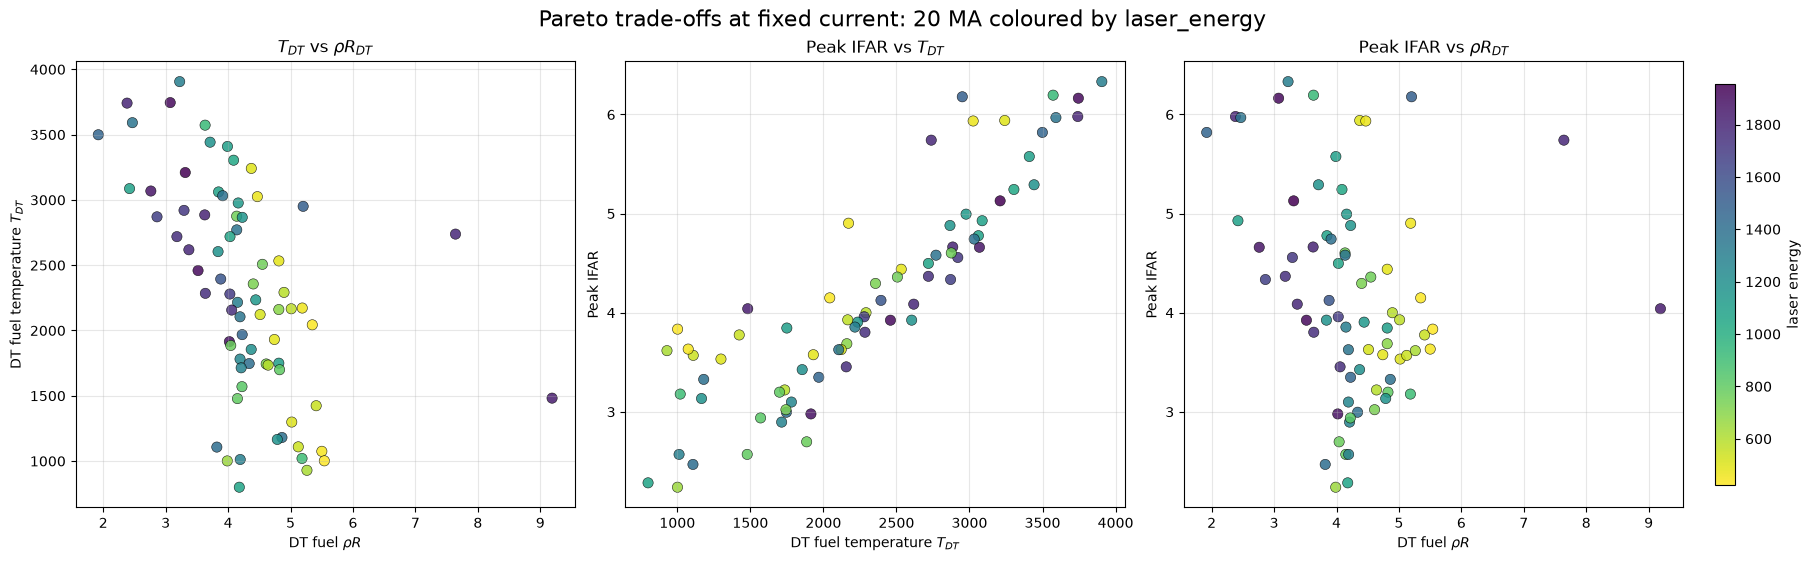

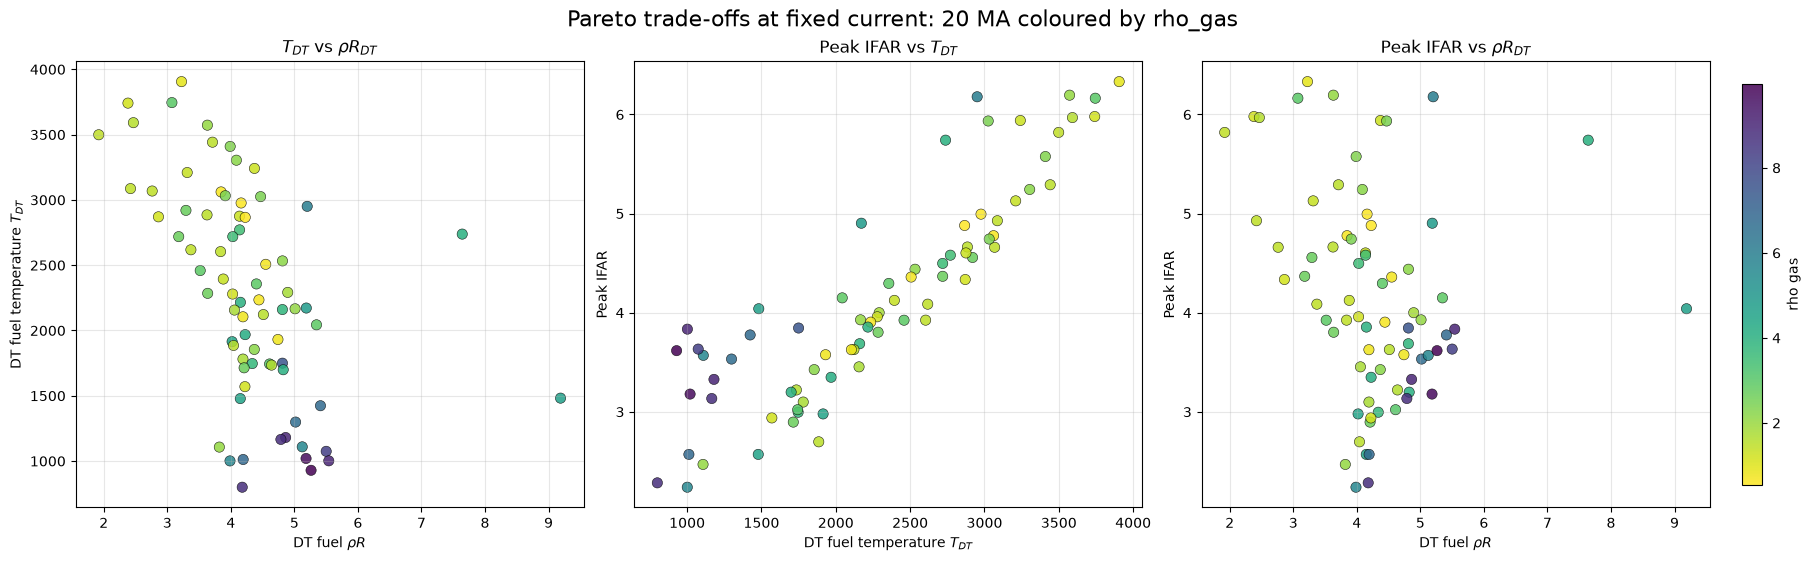

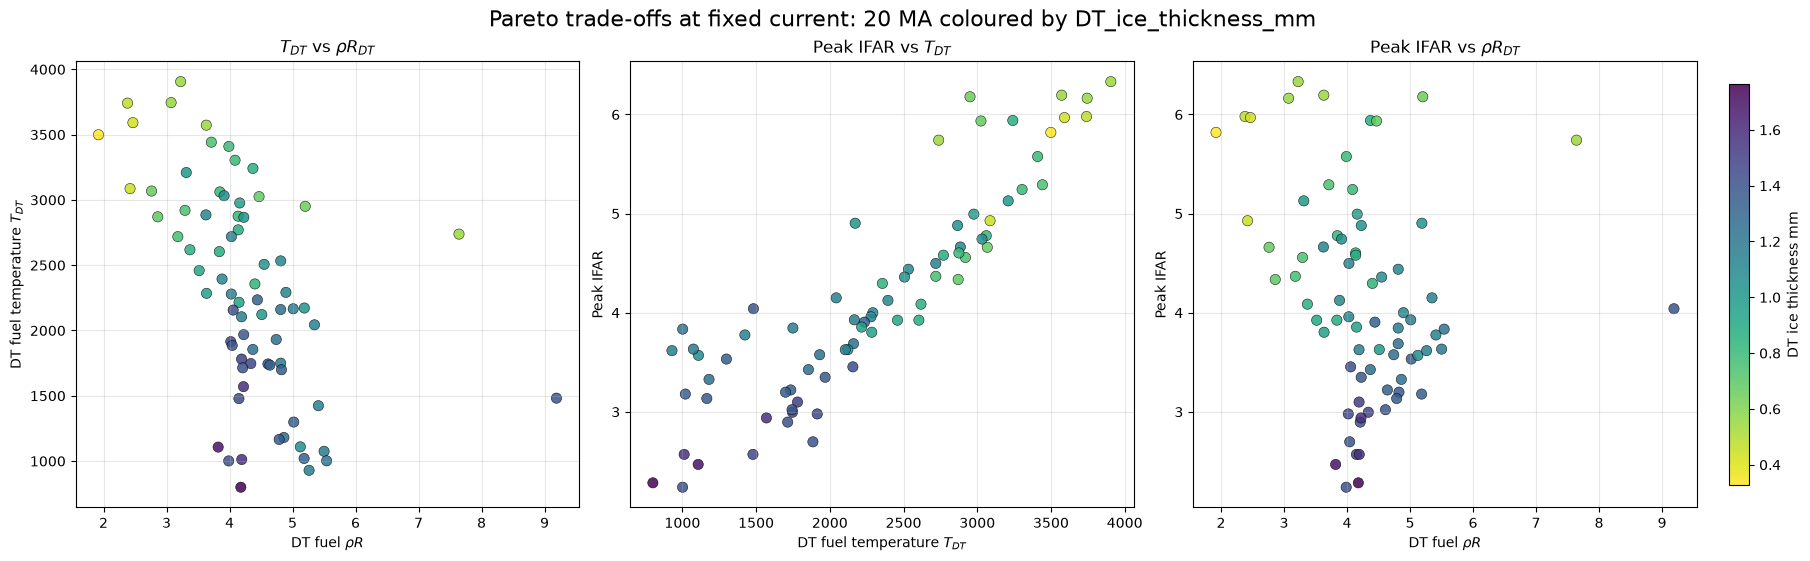

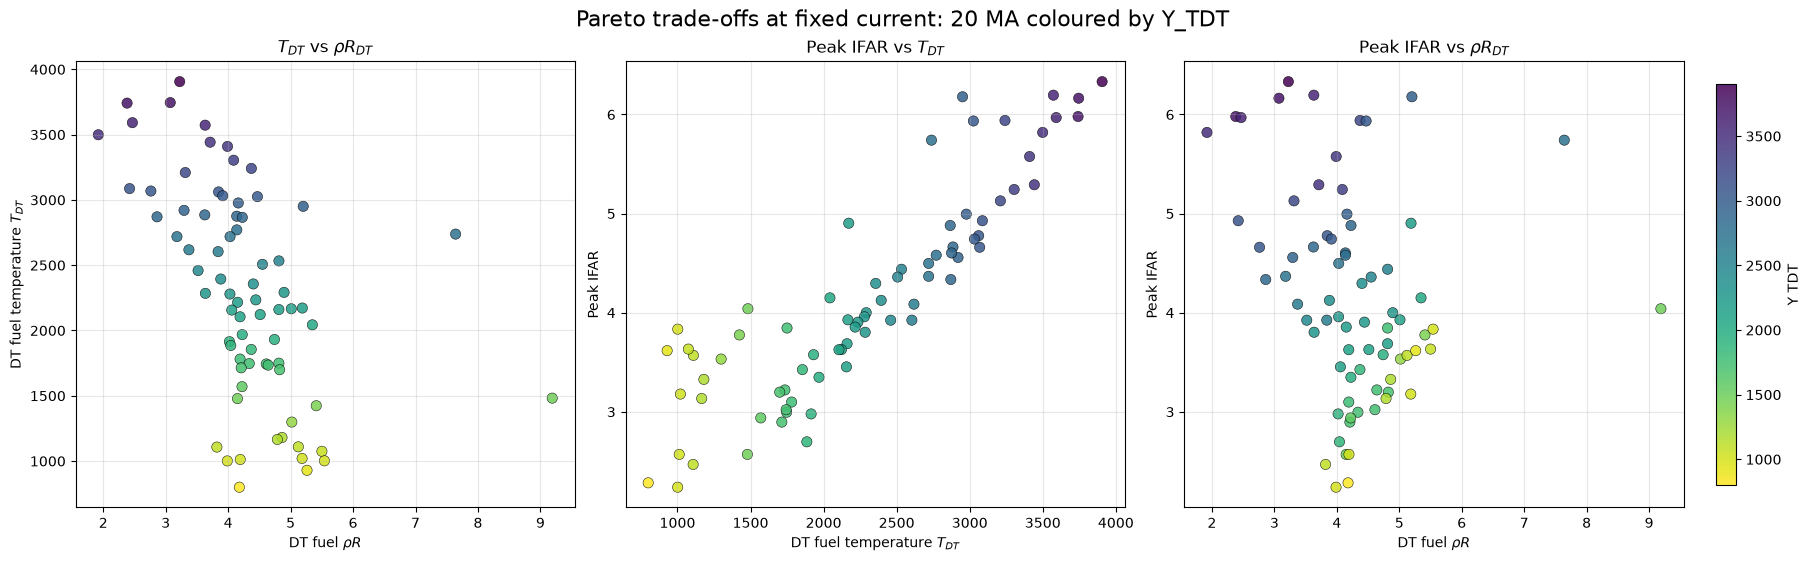

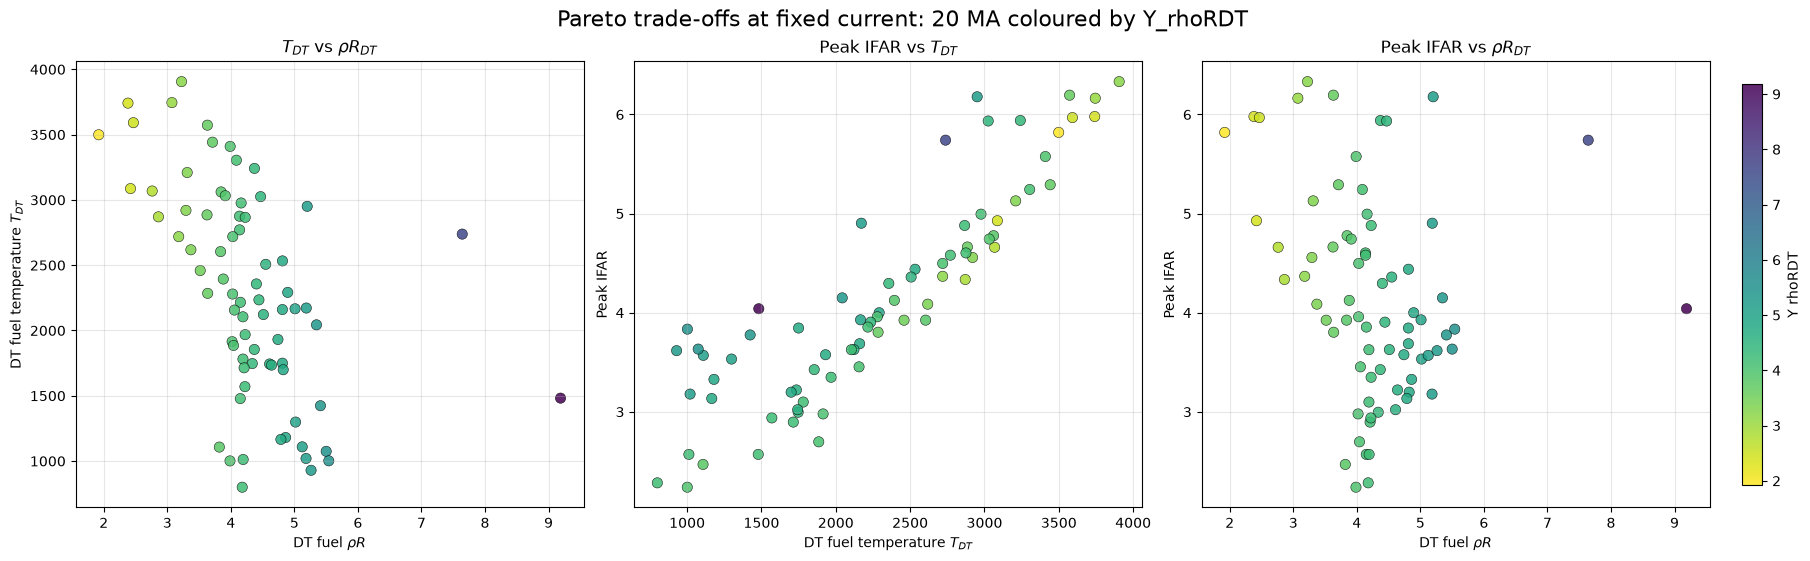

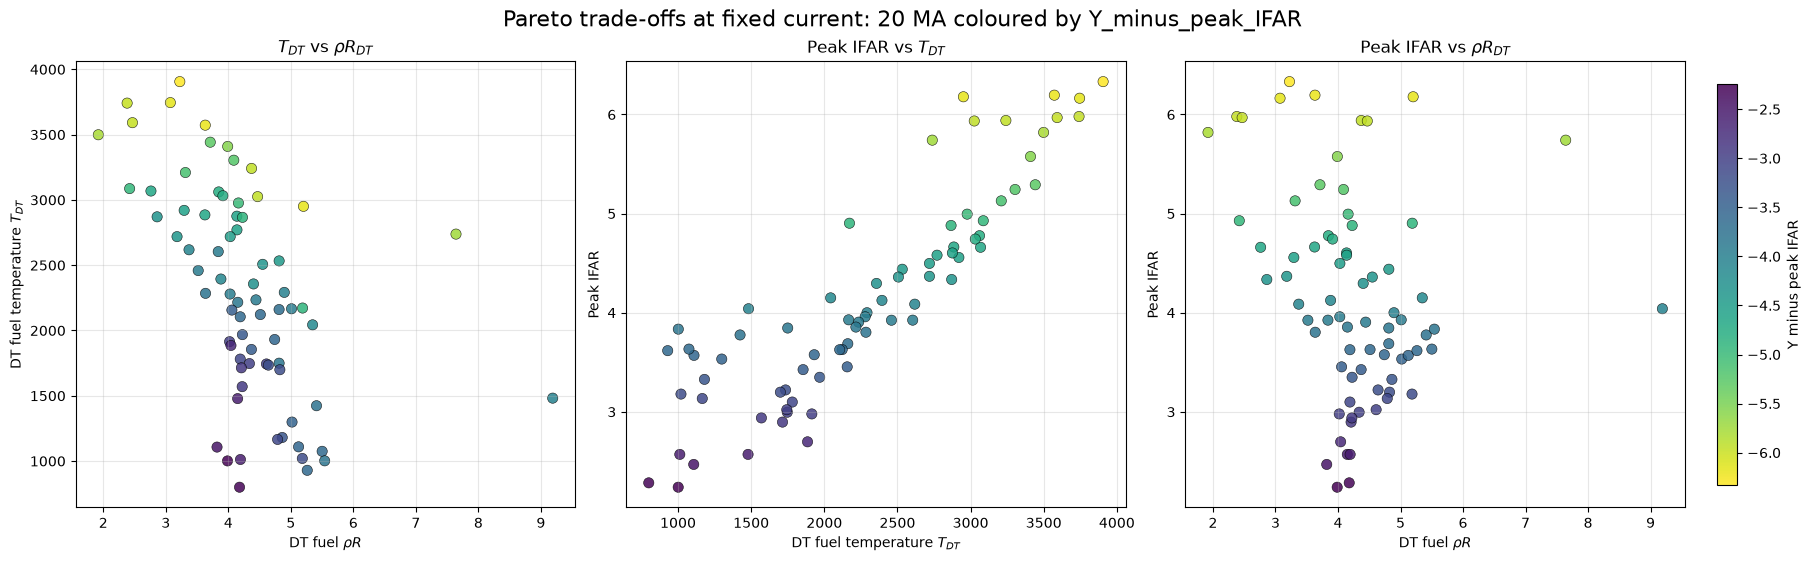

In [7]:
for col in cols:
    plot_pareto_tradeoffs(
    pareto_df,
    colour_by=col,
)


In [8]:
columns = [
    "DT_ice_thickness_mm",
    "T_DT",
    "rhoR_DT",
    "peak_IFAR",
]

print(
    pareto_df[columns]
    .corr(method="spearman")
    .round(3)
)

                     DT_ice_thickness_mm   T_DT  rhoR_DT  peak_IFAR
DT_ice_thickness_mm                1.000 -0.855    0.439     -0.897
T_DT                              -0.855  1.000   -0.613      0.903
rhoR_DT                            0.439 -0.613    1.000     -0.330
peak_IFAR                         -0.897  0.903   -0.330      1.000


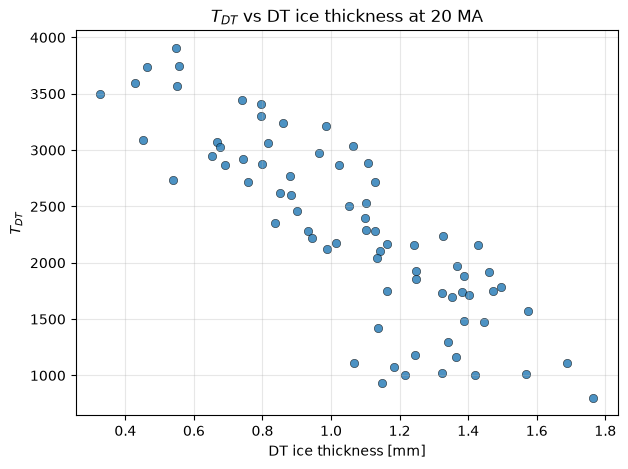

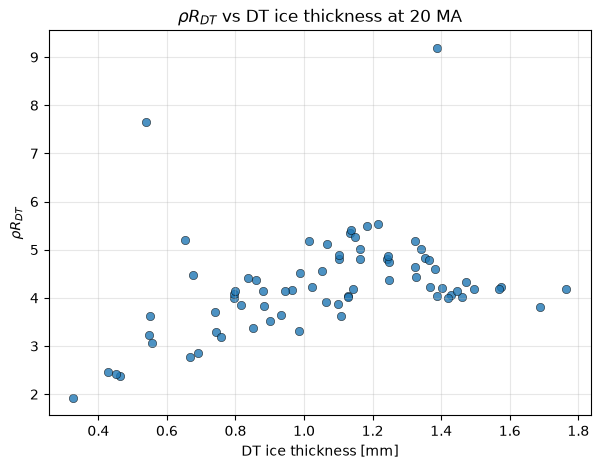

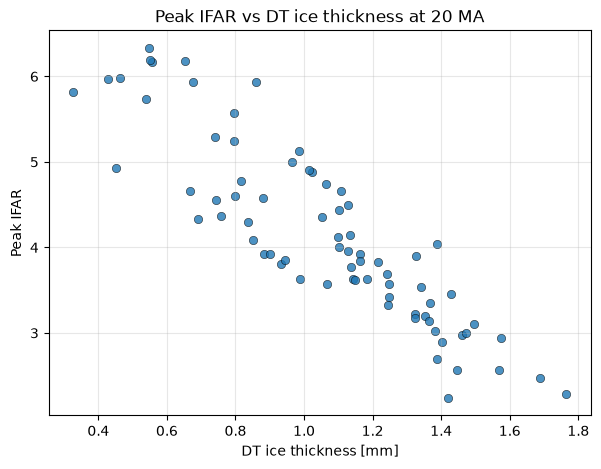

In [9]:
import matplotlib.pyplot as plt

relationships = [
    ("T_DT", r"$T_{DT}$"),
    ("rhoR_DT", r"$\rho R_{DT}$"),
    ("peak_IFAR", "Peak IFAR"),
]

for y_column, y_label in relationships:
    plt.figure(figsize=(7, 5))

    plt.scatter(
        pareto_df["DT_ice_thickness_mm"],
        pareto_df[y_column],
        alpha=0.8,
        edgecolors="black",
        linewidths=0.4,
    )

    plt.xlabel("DT ice thickness [mm]")
    plt.ylabel(y_label)
    plt.title(f"{y_label} vs DT ice thickness at 20 MA")
    plt.grid(alpha=0.3)
    plt.show()